In [1]:
import pandas as pd
import seaborn as sns
#import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from pprint import pprint
#from html_table_parser.parser import HTMLTableParser
from yahooquery import Ticker
import plotly.graph_objects as go
pd.options.display.float_format = '{:,}'.format
import datetime as dt
from datetime import datetime
from sklearn.model_selection import cross_val_score,RepeatedKFold,RepeatedKFold,train_test_split
#import yfinance as yf
import math
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score,mean_squared_error
#from fredapi import Fred
from pandas_datareader import data as pdr

pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Collection

In [2]:
#inflation
inflation = pdr.get_data_fred('CPIAUCSL').pct_change(periods=12) * 100
#employment - non farming
employment_nonfarm = pdr.get_data_fred('PAYEMS')#.pct_change(periods=12) * 100
#employment - non farming
thirtyr = pdr.get_data_fred('MORTGAGE30US')#.pct_change(periods=12) * 100
#employment - non farming
fedfunds = pdr.get_data_fred('FEDFUNDS')#.pct_change(periods=12) * 100
#interest - non farming
unemployment = pdr.get_data_fred('UNRATENSA')#.pct_change(periods=12) * 100
#employment - non farming
delinquencies = pdr.get_data_fred('DRCLACBS')#.pct_change(periods=12) * 100


C:\Users\pbv01\AppData\Local\Temp\ipykernel_31368\4130711514.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation = pdr.get_data_fred('CPIAUCSL').pct_change(periods=12) * 100


In [3]:
thirtyr.sort_values(by='DATE', ascending=False).head()

,MORTGAGE30US
DATE,
2026-06-11,6.520
2026-06-04,6.480
2026-05-28,6.530
2026-05-21,6.510
2026-05-14,6.360


In [4]:
print(inflation.index.to_list())
print(employment_nonfarm.index.to_list())
print(thirtyr.index.to_list())
print(fedfunds.index.to_list())
print(unemployment.index.to_list())
print(delinquencies.index.to_list())

[Timestamp('2021-07-01 00:00:00'), Timestamp('2021-08-01 00:00:00'), Timestamp('2021-09-01 00:00:00'), Timestamp('2021-10-01 00:00:00'), Timestamp('2021-11-01 00:00:00'), Timestamp('2021-12-01 00:00:00'), Timestamp('2022-01-01 00:00:00'), Timestamp('2022-02-01 00:00:00'), Timestamp('2022-03-01 00:00:00'), Timestamp('2022-04-01 00:00:00'), Timestamp('2022-05-01 00:00:00'), Timestamp('2022-06-01 00:00:00'), Timestamp('2022-07-01 00:00:00'), Timestamp('2022-08-01 00:00:00'), Timestamp('2022-09-01 00:00:00'), Timestamp('2022-10-01 00:00:00'), Timestamp('2022-11-01 00:00:00'), Timestamp('2022-12-01 00:00:00'), Timestamp('2023-01-01 00:00:00'), Timestamp('2023-02-01 00:00:00'), Timestamp('2023-03-01 00:00:00'), Timestamp('2023-04-01 00:00:00'), Timestamp('2023-05-01 00:00:00'), Timestamp('2023-06-01 00:00:00'), Timestamp('2023-07-01 00:00:00'), Timestamp('2023-08-01 00:00:00'), Timestamp('2023-09-01 00:00:00'), Timestamp('2023-10-01 00:00:00'), Timestamp('2023-11-01 00:00:00'), Timestamp('20

In [5]:
#dim date
start = "2021-07-01"
end = pd.Timestamp.today().normalize()  # or "today"
months = pd.date_range(start=start, end=end, freq="MS")  # month starts

dim_date = pd.DataFrame({"month": months})
dim_date["month_str"] = dim_date["month"].dt.strftime("%Y-%m")

In [6]:
df = dim_date.merge(inflation, left_on='month',right_index=True,how='left')
df = df.merge(employment_nonfarm, left_on='month',right_index=True,how='left')
df = df.merge(thirtyr, left_on='month',right_index=True,how='left')
df = df.merge(fedfunds, left_on='month',right_index=True,how='left')
df = df.merge(unemployment, left_on='month',right_index=True,how='left')
df = df.merge(delinquencies, left_on='month',right_index=True,how='left')

df = df.iloc[:-1,]

In [7]:
df.head()

,month,month_str,CPIAUCSL,PAYEMS,MORTGAGE30US,FEDFUNDS,UNRATENSA,DRCLACBS
0,2021-07-01,2021-07,NaN,146762.000,2.980,0.100,5.700,1.520
1,2021-08-01,2021-08,NaN,147314.000,NaN,0.090,5.300,NaN
2,2021-09-01,2021-09,NaN,147771.000,NaN,0.080,4.600,NaN
3,2021-10-01,2021-10,NaN,148572.000,NaN,0.080,4.300,1.550
4,2021-11-01,2021-11,NaN,149230.000,NaN,0.080,3.900,NaN


In [8]:
print(df.dtypes)

df.head()

month           datetime64[ns]
month_str               object
CPIAUCSL               float64
PAYEMS                 float64
MORTGAGE30US           float64
FEDFUNDS               float64
UNRATENSA              float64
DRCLACBS               float64
dtype: object


,month,month_str,CPIAUCSL,PAYEMS,MORTGAGE30US,FEDFUNDS,UNRATENSA,DRCLACBS
0,2021-07-01,2021-07,NaN,146762.000,2.980,0.100,5.700,1.520
1,2021-08-01,2021-08,NaN,147314.000,NaN,0.090,5.300,NaN
2,2021-09-01,2021-09,NaN,147771.000,NaN,0.080,4.600,NaN
3,2021-10-01,2021-10,NaN,148572.000,NaN,0.080,4.300,1.550
4,2021-11-01,2021-11,NaN,149230.000,NaN,0.080,3.900,NaN


# Visualization

<Axes: xlabel='month', ylabel='CPIAUCSL'>

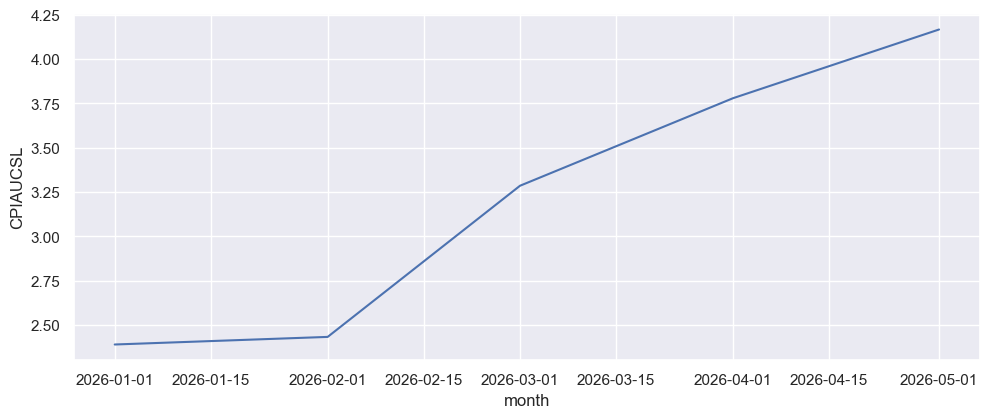

In [14]:
sns.set_theme(rc={'figure.figsize':(11.7,4.5)})
sns.lineplot(df[df['month']>='2026-01-01'], x='month', y='CPIAUCSL')

<Axes: xlabel='month', ylabel='MORTGAGE30US'>

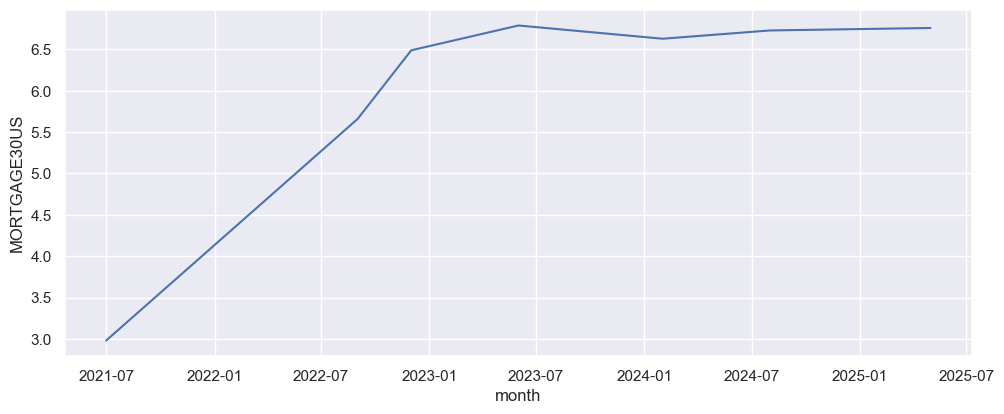

In [13]:
sns.set_theme(rc={'figure.figsize':(11.7,4.5)})
sns.lineplot(df, x='month', y='MORTGAGE30US')

In [ ]:
employed = pd.DataFrame(fred.get_series('PAYEMS')).reset_index() #mortgage rates
employed['employed_difference'] = employed[0] - employed[0].shift(1)
employed['employed_difference'] = employed['employed_difference']*1000
employed.columns = ['date','employed','employed_difference']

In [43]:
fred.search('PAYEMS').head(5)

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
PAYEMS,PAYEMS,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Seasonally Adjusted,SA,2026-06-05 08:31:36-05:00,86,"All Employees: Total Nonfarm, commonly known a..."
PAYNSA,PAYNSA,2026-06-13,2026-06-13,"All Employees, Total Nonfarm",1939-01-01,2026-05-01,Monthly,M,Thousands of Persons,Thous. of Persons,Not Seasonally Adjusted,NSA,2026-06-05 08:30:45-05:00,54,"All Employees: Total Nonfarm, commonly known a..."


In [ ]:



thirtyr = pd.DataFrame(fred.get_series('MORTGAGE30US')).reset_index() #mortgage rates
fedfunds = pd.DataFrame(fred.get_series('FEDFUNDS')).reset_index() #rates
unemployment = pd.DataFrame(fred.get_series('UNRATENSA')).reset_index() #unemployment
delq_loans = pd.DataFrame(fred.get_series('DRCLACBS')).reset_index() #delinquencies

thirtyr.columns = ['date','30yrmtg']
fedfunds.columns = ['date','fedfunds']
unemployment.columns = ['date','unemployment']
delq_loans.columns = ['date','delinquencies']